# Taxi Trip Cleanup

In this notebook we clean the taxi trip data provided by the city of chicago: https://data.cityofchicago.org/Transportation/Taxi-Trips-2024-/ajtu-isnz/about_data (downloaded on 05.05.2026).

In [86]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd

# import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.stats import zscore

import geopandas as gpd
import h3

In [87]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

raw_data= pd.read_csv("../../data/trips/CHICAGO_TAXI_TRIPS_2025.csv")

In [88]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data overview.                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Raw data shape: {raw_data.shape}")
print(f"Raw data info:")
print(raw_data.info())
print(f"Raw data columns: {list(raw_data.columns)}")
raw_data.head()

Raw data shape: (6825838, 23)
Raw data info:
<class 'pandas.DataFrame'>
RangeIndex: 6825838 entries, 0 to 6825837
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   trip_id                     str    
 1   taxi_id                     str    
 2   trip_start_timestamp        str    
 3   trip_end_timestamp          str    
 4   trip_seconds                float64
 5   trip_miles                  float64
 6   pickup_census_tract         float64
 7   dropoff_census_tract        float64
 8   pickup_community_area       float64
 9   dropoff_community_area      float64
 10  fare                        float64
 11  tips                        float64
 12  tolls                       float64
 13  extras                      float64
 14  trip_total                  float64
 15  payment_type                str    
 16  company                     str    
 17  pickup_centroid_latitude    float64
 18  pickup_centroid_longitude   

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01T00:00:00.000,2025-01-01T00:15:00.000,758.0,2.93,NaN,NaN,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01T00:00:00.000,2025-01-01T00:15:00.000,1233.0,13.66,NaN,NaN,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
2,060f692c4ca69e552c07a97c99715ad51112470e,e533bfdc483206f9c02c1c879a118d88f0a3ca1cd2703f...,2025-01-01T00:00:00.000,2025-01-01T00:00:00.000,6.0,0.00,NaN,NaN,6.0,6.0,...,0.0,30.50,Credit Card,Flash Cab,41.944227,-87.655998,POINT (-87.6559981815 41.9442266014),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
3,0b2d1368456148b049af41dc8aa565d688081756,2d5029b701200a2ab66bd5071f743efe20a3036597d2b3...,2025-01-01T00:00:00.000,2025-01-01T00:00:00.000,11.0,0.00,NaN,NaN,77.0,77.0,...,0.0,25.62,Credit Card,Sun Taxi,41.986712,-87.663416,POINT (-87.6634164054 41.9867117999),41.986712,-87.663416,POINT (-87.6634164054 41.9867117999)
4,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01T00:00:00.000,2025-01-01T00:15:00.000,985.0,3.22,NaN,NaN,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)


In [89]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data type referencing                   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# turn strings to numeric values
stringToNumeric = ["trip_miles", "fare", "tips", "tolls", "extras", "trip_total"]
raw_data[stringToNumeric] = raw_data[stringToNumeric].apply(
    lambda s: pd.to_numeric(
        s.astype(str)
         .str.replace("$", "", regex=False)
         .str.replace(",", ".", regex=False),
        errors="coerce"
    )
)


# Change type of Trip_Start_Timestamp and Trip_End_Timestamp to datetime object
raw_data["trip_start_timestamp"] = pd.to_datetime(
    raw_data["trip_start_timestamp"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

raw_data["trip_end_timestamp"] = pd.to_datetime(
    raw_data["trip_end_timestamp"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6825838 entries, 0 to 6825837
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[us]
 3   trip_end_timestamp          datetime64[us]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_census_tract         float64       
 7   dropoff_census_tract        float64       
 8   pickup_community_area       float64       
 9   dropoff_community_area      float64       
 10  fare                        float64       
 11  tips                        float64       
 12  tolls                       float64       
 13  extras                      float64       
 14  trip_total                  float64       
 15  payment_type                str           
 16  company                     s

In [90]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Check Time Range                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print("Start Timestamp range:", raw_data["trip_start_timestamp"].min(), "to", raw_data["trip_start_timestamp"].max())

Start Timestamp range: 2025-01-01 00:00:00 to 2025-12-31 23:45:00


In [91]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove Duplicates                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Check for duplicates
n_duplicates = raw_data.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

# Check if any trip ids are duplicate
n_duplicate_trip_ids = raw_data["trip_id"].duplicated().sum()
print(f"Number of duplicated Trip IDs: {n_duplicate_trip_ids}")

Number of duplicate rows: 0
Number of duplicated Trip IDs: 0


In [92]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove N/A-values                       #
#  (only non-location data)               #
# # # # # # # # # # # # # # # # # # # # # #

# Check for NA values
na_summary = (
    raw_data
    .isna()
    .sum()
    .to_frame(name="Null Count")
    .assign(
        Null_Percent=lambda x: (x["Null Count"] / len(raw_data) * 100).round(2)
    )
)
na_summary

,Null Count,Null_Percent
trip_id,0,0.00
taxi_id,9,0.00
trip_start_timestamp,0,0.00
trip_end_timestamp,128,0.00
trip_seconds,1286,0.02
trip_miles,63,0.00
pickup_census_tract,3745888,54.88
dropoff_census_tract,3833965,56.17
pickup_community_area,186738,2.74
dropoff_community_area,587238,8.60


In [93]:
# Set the columns to check for NA values (e.g., exclude location columns)
columns_to_check = ['taxi_id', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', "fare", "tips", "tolls", "extras", "trip_total"]  # change as needed

# Calculate how many rows would be removed if NA in these columns only
removed_na = raw_data.shape[0] - raw_data.dropna(subset=columns_to_check).shape[0]
removed_rel_share = (removed_na / raw_data.shape[0]) * 100

print(f'Dropping rows with NA in {columns_to_check} would remove {removed_na} rows ({removed_rel_share:.2f}%) of the dataset.')


Dropping rows with NA in ['taxi_id', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'fare', 'tips', 'tolls', 'extras', 'trip_total'] would remove 12511 rows (0.18%) of the dataset.


In [94]:
# Remove na values, since only 0.18% of the dataset
raw_data = raw_data.dropna(subset=columns_to_check)

In [95]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Trip Data Cleaning                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Trip miles < 0
n_negative_miles = (raw_data["trip_miles"] <= 0).sum()
print(f"Number of negative trip miles: {n_negative_miles}")

# Trip seconds < 60 (s)
n_seconds_less_min = (raw_data["trip_seconds"] < 60).sum()
print(f"Number of trips faster than 1 min: {n_seconds_less_min}")

# Remove negative trip miles and trips faster than 60s
raw_data = raw_data[((raw_data["trip_miles"] > 0) & (raw_data["trip_seconds"] >= 60))]

overlapping_trips = raw_data.groupby('taxi_id').apply(
    lambda group: group[
        (group['trip_start_timestamp'].lt(group['trip_end_timestamp'].shift(-1))) &
        (group['trip_end_timestamp'].gt(group['trip_start_timestamp'].shift(-1)))
    ]
)
print("Number of Taxi IDs with overlapping operation time periods:", len(overlapping_trips))
overlapping_trips

# assumption: if there are overlapping trips with the same taxi id, there was something wrong with all of these trips, so therefore we remove all of the overlapping trips
overlapping_trips_indices = overlapping_trips.index.get_level_values(1)
raw_data = raw_data.drop(overlapping_trips_indices, axis= 0)


Number of negative trip miles: 528445
Number of trips faster than 1 min: 381486
Number of Taxi IDs with overlapping operation time periods: 28320


In [96]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Price Data                              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# check for total_prices <= 0
# since tips, tolls and extras are dependent on the details of the trips and might be 0, it is okay for them to be 0.
# Fares are mandatory and have to be greater than 0

fare_check = (raw_data['fare'] <= 0).sum()
tips_check = (raw_data['tips'] < 0).sum()
tolls_check = (raw_data['tolls'] < 0).sum()
extras_check = (raw_data['extras'] < 0).sum()
print("Number of entries with fares <= 0:", fare_check)
print("Number of entries with tips <= 0:", tips_check)
print("Number of entries with tolls <= 0:", tolls_check)
print("Number of entries with extras <= 0:", extras_check)

# remove negative or 0 fares
raw_data = raw_data[raw_data["fare"] > 0]
raw_data.reset_index(drop=True)

Number of entries with fares <= 0: 1455
Number of entries with tips <= 0: 0
Number of entries with tolls <= 0: 0
Number of entries with extras <= 0: 0


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01 00:00:00,2025-01-01 00:15:00,758.0,2.93,NaN,NaN,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01 00:00:00,2025-01-01 00:15:00,1233.0,13.66,NaN,NaN,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01 00:00:00,2025-01-01 00:15:00,985.0,3.22,NaN,NaN,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01 00:00:00,2025-01-01 00:15:00,652.0,3.24,NaN,NaN,22.0,7.0,...,0.0,15.67,Mobile,Tac - Yellow Cab Association,41.922761,-87.699155,POINT (-87.6991553432 41.9227606205),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01 00:00:00,2025-01-01 00:15:00,803.0,6.09,NaN,NaN,8.0,3.0,...,1.0,18.50,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6188264,f19c5c32205e7fb37b7ff564da1146484259f8fb,3ae83cc261cea27eafc3d9b18bbc93100c03762e8b6971...,2025-12-31 23:45:00,2026-01-01 00:00:00,960.0,1.70,1.703108e+10,NaN,8.0,NaN,...,0.0,9.50,Cash,Transit Administrative Center Inc,41.895033,-87.619711,POINT (-87.6197106717 41.8950334495),NaN,NaN,NaN
6188265,f1f4fd1497483c42e0f597b0d4e23fef46512bd0,8ac81cfa2ee2c29b19f8fa21ed92b908d46bedc9d4055c...,2025-12-31 23:45:00,2025-12-31 23:45:00,480.0,1.10,NaN,NaN,32.0,32.0,...,1.0,7.75,Cash,Choice Taxi Association Inc,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.878866,-87.625192,POINT (-87.6251921424 41.8788655841)
6188266,f25fea09e509dc84b861f98c47cb557701718ffd,54f9ba36584d6915e95cdf3394cdc46ed49c4a57cb0eb2...,2025-12-31 23:45:00,2026-01-01 00:00:00,632.0,3.59,NaN,NaN,32.0,33.0,...,1.0,13.50,Cash,Sun Taxi,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.857184,-87.620335,POINT (-87.6203346241 41.8571838585)
6188267,f6181757bf371eb4d0480e052ed2723d58750bfc,17a313ad40ea410818634782c7202abda7ce5289dc03f9...,2025-12-31 23:45:00,2026-01-01 00:00:00,679.0,2.71,NaN,NaN,8.0,24.0,...,0.0,13.75,Mobile,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.901207,-87.676356,POINT (-87.6763559892 41.9012069941)


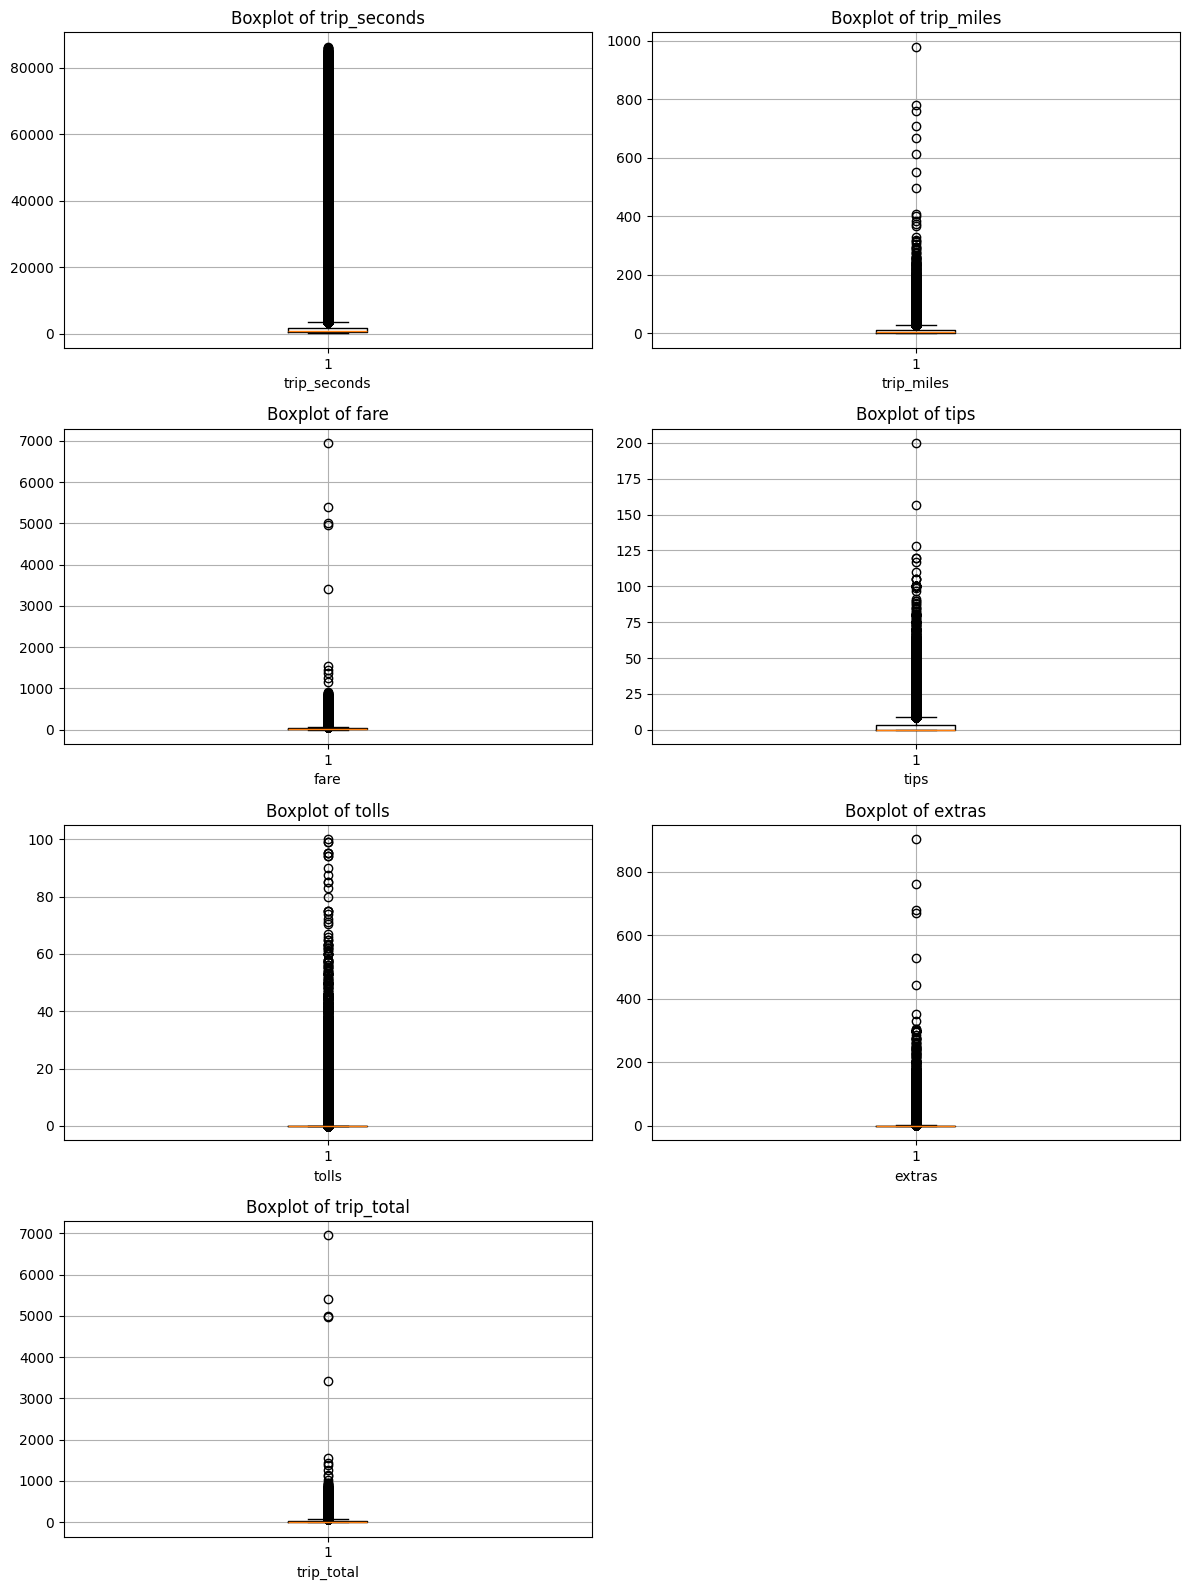

In [97]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Detection                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

numeric_columns = ["trip_seconds", "trip_miles", "fare", "tips", "tolls", "extras", "trip_total"]

# 2 plots per row
rows = math.ceil(len(numeric_columns) / 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    data = pd.to_numeric(raw_data[col], errors='coerce').dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].grid(True)

# Remove any unused axes
for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [98]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Removal: Statistical Solution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zscore_threshold = 2
outlier_indices_per_column = {}
all_outlier_indices = set()

# remove outliers based on z-score
for col in numeric_columns:
    # Replace zeros with NaN and filter out non-positive values
    safe_col = raw_data[col].replace(0, np.nan)
    safe_col = safe_col[safe_col > 0]
    
    if safe_col.empty:
        continue
    
    # Log-transform and compute z-score
    log_transformed = np.log(safe_col)
    zscores = np.abs(zscore(log_transformed))
    zscore_series = pd.Series(zscores, index=log_transformed.index)

    # Find outliers
    outlier_indices = zscore_series[zscore_series > zscore_threshold].index
    outlier_indices_per_column[col] = list(outlier_indices)
    all_outlier_indices.update(outlier_indices)

    print(f"--> {len(outlier_indices)} outliers detected in '{col}'")

# Drop all outliers at once
total_rows = len(raw_data) # for dropped percentage of dataset
df_cleaned = raw_data.drop(index=all_outlier_indices).reset_index(drop=True)

removed_rows = len(all_outlier_indices)
removed_percentage = round((removed_rows / total_rows) * 100, 2)

print(f"\nOutlier detection completed. Total rows removed: {len(all_outlier_indices)}, {removed_percentage}%")

--> 219894 outliers detected in 'trip_seconds'
--> 94276 outliers detected in 'trip_miles'
--> 55121 outliers detected in 'fare'
--> 52309 outliers detected in 'tips'
--> 2683 outliers detected in 'tolls'
--> 127168 outliers detected in 'extras'
--> 96280 outliers detected in 'trip_total'

Outlier detection completed. Total rows removed: 444100, 7.18%


In [99]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Location data imputation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- 1) Fix comma-decimal coordinates ---
coord_cols = [
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "dropoff_centroid_latitude", "dropoff_centroid_longitude"
]

raw_data[coord_cols] = raw_data[coord_cols].apply(
    lambda s: pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False),
                            errors="coerce")
)

# --- 2) Load tract polygons ---
tracts = gpd.read_file("../../data/Census_Tracts_Chicago.geojson").to_crs(4326)
TRACT_COL = "census_t_1"

centroids = tracts.set_index(TRACT_COL).geometry.centroid

# --- 3) Helper: fill missing tracts from coords ---
def fill_tract(lat_col, lon_col, tract_col):
    mask = raw_data[tract_col].isna() & raw_data[lat_col].notna()
    if mask.any():
        pts = gpd.GeoDataFrame(
            geometry=gpd.points_from_xy(raw_data.loc[mask, lon_col],
                                        raw_data.loc[mask, lat_col]),
            crs=4326,
            index=raw_data.index[mask]
        )
        joined = gpd.sjoin(pts, tracts[[TRACT_COL, "geometry"]],
                           how="left", predicate="within")
        raw_data.loc[joined.index, tract_col] = joined[TRACT_COL].values

# --- 4) Helper: fill missing coords from tract ---
def fill_coords(lat_col, lon_col, tract_col):
    mask = raw_data[tract_col].notna() & raw_data[lat_col].isna()
    if mask.any():
        c = centroids.reindex(raw_data.loc[mask, tract_col].astype(str))
        raw_data.loc[mask, lat_col] = c.y.values
        raw_data.loc[mask, lon_col] = c.x.values

# --- 5) Apply ---
raw_data["pickup_census_tract"] = raw_data["pickup_census_tract"].astype("string")
raw_data["dropoff_census_tract"] = raw_data["dropoff_census_tract"].astype("string")

fill_tract("pickup_centroid_latitude", "pickup_centroid_longitude", "pickup_census_tract")
fill_tract("dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_census_tract")

fill_coords("pickup_centroid_latitude", "pickup_centroid_longitude", "pickup_census_tract")
fill_coords("dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_census_tract")

print(raw_data.isna().sum())


C:\Users\Yannick Herrmann\AppData\Local\Temp\ipykernel_31144\3623982466.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = tracts.set_index(TRACT_COL).geometry.centroid


trip_id                            0
taxi_id                            0
trip_start_timestamp               0
trip_end_timestamp                 0
trip_seconds                       0
trip_miles                         0
pickup_census_tract           109052
dropoff_census_tract          474639
pickup_community_area         109877
dropoff_community_area        511148
fare                               0
tips                               0
tolls                              0
extras                             0
trip_total                         0
payment_type                       0
company                            0
pickup_centroid_latitude      109158
pickup_centroid_longitude     109158
pickup_centroid_location      109158
dropoff_centroid_latitude     480448
dropoff_centroid_longitude    480448
dropoff_centroid_location     480448
dtype: int64


In [100]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove N/A-values                       #
#  (only non-location data)               #
# # # # # # # # # # # # # # # # # # # # # #

# Check for NA values
na_summary = (
    raw_data
    .isna()
    .sum()
    .to_frame(name="Null Count")
    .assign(
        Null_Percent=lambda x: (x["Null Count"] / len(raw_data) * 100).round(2)
    )
)
na_summary

,Null Count,Null_Percent
trip_id,0,0.00
taxi_id,0,0.00
trip_start_timestamp,0,0.00
trip_end_timestamp,0,0.00
trip_seconds,0,0.00
trip_miles,0,0.00
pickup_census_tract,109052,1.76
dropoff_census_tract,474639,7.67
pickup_community_area,109877,1.78
dropoff_community_area,511148,8.26


In [101]:
# Set the columns to check for NA values (e.g., exclude location columns)
columns_to_remove = ["pickup_census_tract", "dropoff_census_tract", "pickup_community_area", "dropoff_community_area", "pickup_centroid_latitude", "pickup_centroid_longitude", "pickup_centroid_location", "dropoff_centroid_latitude", "dropoff_centroid_longitude", "dropoff_centroid_location"]

# Calculate how many rows would be removed if NA in these columns only
removed_na = raw_data.shape[0] - raw_data.dropna(subset=columns_to_remove).shape[0]
removed_rel_share = (removed_na / raw_data.shape[0]) * 100

print(f'Dropping rows with NA in {columns_to_remove} would remove {removed_na} rows ({removed_rel_share:.2f}%) of the dataset of {raw_data.shape[0]} rows.')


Dropping rows with NA in ['pickup_census_tract', 'dropoff_census_tract', 'pickup_community_area', 'dropoff_community_area', 'pickup_centroid_latitude', 'pickup_centroid_longitude', 'pickup_centroid_location', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'dropoff_centroid_location'] would remove 551090 rows (8.91%) of the dataset of 6188269 rows.


### Removing all N/A values from the dataset would remove another 8.91% of the dataset. We consider this as acceptable (since the entirety of the dataset is still 6.19m records), therefore we throw out all the N/A values.

In [102]:
# Remove na values, see upper cell
raw_data = raw_data.dropna(subset=columns_to_remove)

In [103]:
raw_data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,17031081000,17031081000,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,17031760900,17031062200,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
4,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,17031081000,17031071100,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
5,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,17031221300,17031071100,22.0,7.0,...,0.0,15.67,Mobile,Tac - Yellow Cab Association,41.922761,-87.699155,POINT (-87.6991553432 41.9227606205),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
6,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,17031081000,17031031600,8.0,3.0,...,1.0,18.50,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)


In [104]:
# write cleaned dataframe into .parquet file
# raw_data.to_csv("../../data/trips/trips_cleaned_V1.csv",index=None)

# 2. Spatial Data

In [105]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Spatial Resolution                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# apply uber's h3 hexagonal distribution for pickup and dropoff locations

# define resolutions
resolutions = {
    'low': 6,
    'medium': 7,
    'high': 8
}

# map resolutions on data
for res_name, res_level in resolutions.items():
    raw_data[f'pickup_h3_{res_name}_resolution'] = list(map(
        lambda lat, lon: h3.latlng_to_cell(lat, lon, res_level),
        raw_data['pickup_centroid_latitude'],
        raw_data['pickup_centroid_longitude']
    ))

    raw_data[f'dropoff_h3_{res_name}_resolution'] = list(map(
        lambda lat, lon: h3.latlng_to_cell(lat, lon, res_level),
        raw_data['dropoff_centroid_latitude'],
        raw_data['dropoff_centroid_longitude']
    ))


In [106]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Year, month, day extraction             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

raw_data["start_year"] = raw_data["trip_start_timestamp"].dt.year
raw_data["start_month"] = raw_data["trip_start_timestamp"].dt.month
raw_data["start_hour"]  = raw_data["trip_start_timestamp"].dt.hour

In [107]:
# write cleaned dataframe into .parquet file
raw_data.to_csv("../../data/trips/trips_cleaned_V1.csv",index=None)

In [108]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load weather data                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

weather = pd.read_csv("../../data/weather/weather_hourly.csv")
print(weather.shape)
weather.head()

(17568, 15)


,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,2024-01-01 00:00:00+00:00,-7.50,73.624560,-12.272507,0.0,0.0,0.0,0.0,891.08750,11.0,9.693296,13.797912,0.0,0.0,0.0
1,2024-01-01 01:00:00+00:00,-8.20,74.677930,-13.002723,0.0,0.0,0.0,0.0,890.57184,20.0,9.659814,12.429127,0.0,0.0,0.0
2,2024-01-01 02:00:00+00:00,-8.75,75.177630,-13.529382,0.0,0.0,0.0,0.0,889.95590,35.0,9.290511,9.693295,0.0,0.0,0.0
3,2024-01-01 03:00:00+00:00,-9.20,75.398346,-13.913002,0.0,0.0,0.0,0.0,889.04440,92.0,8.654987,6.489992,0.0,0.0,0.0
4,2024-01-01 04:00:00+00:00,-9.25,75.085120,-13.931759,0.0,0.0,0.0,0.0,888.67505,100.0,8.396570,3.415260,0.0,0.0,0.0


In [109]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 17568 entries, 0 to 17567
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  17568 non-null  str    
 1   temperature_2m        17568 non-null  float64
 2   relative_humidity_2m  17568 non-null  float64
 3   apparent_temperature  17568 non-null  float64
 4   precipitation         17568 non-null  float64
 5   rain                  17568 non-null  float64
 6   snowfall              17568 non-null  float64
 7   snow_depth            17568 non-null  float64
 8   surface_pressure      17568 non-null  float64
 9   cloud_cover           17568 non-null  float64
 10  wind_speed_10m        17568 non-null  float64
 11  wind_speed_100m       17568 non-null  float64
 12  is_day                17568 non-null  float64
 13  sunshine_duration     17568 non-null  float64
 14  direct_radiation      17568 non-null  float64
dtypes: float64(14), str(1)
memory 

In [110]:
display(weather)

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,2024-01-01 00:00:00+00:00,-7.50,73.624560,-12.272507,0.0,0.0,0.0,0.0,891.08750,11.0,9.693296,13.797912,0.0,0.0000,0.0
1,2024-01-01 01:00:00+00:00,-8.20,74.677930,-13.002723,0.0,0.0,0.0,0.0,890.57184,20.0,9.659814,12.429127,0.0,0.0000,0.0
2,2024-01-01 02:00:00+00:00,-8.75,75.177630,-13.529382,0.0,0.0,0.0,0.0,889.95590,35.0,9.290511,9.693295,0.0,0.0000,0.0
3,2024-01-01 03:00:00+00:00,-9.20,75.398346,-13.913002,0.0,0.0,0.0,0.0,889.04440,92.0,8.654987,6.489992,0.0,0.0000,0.0
4,2024-01-01 04:00:00+00:00,-9.25,75.085120,-13.931759,0.0,0.0,0.0,0.0,888.67505,100.0,8.396570,3.415260,0.0,0.0000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17563,2026-01-01 19:00:00+00:00,-4.85,66.939950,-8.355146,0.0,0.0,0.0,0.0,892.97750,0.0,1.698117,2.705993,0.0,1296.0045,7.0
17564,2026-01-01 20:00:00+00:00,-5.55,70.862970,-9.118733,0.0,0.0,0.0,0.0,892.38086,0.0,2.160000,0.763675,0.0,0.0000,0.0
17565,2026-01-01 21:00:00+00:00,-6.35,74.137620,-10.239040,0.0,0.0,0.0,0.0,892.33856,0.0,4.248152,0.254558,0.0,0.0000,0.0
17566,2026-01-01 22:00:00+00:00,-6.95,75.506676,-10.972478,0.0,0.0,0.0,0.0,892.21875,0.0,4.978554,1.800000,0.0,0.0000,0.0


weather timestamps are UTC-aware; convert to Chicago local time and strip tz:

In [111]:
weather["date"] = (
    pd.to_datetime(weather["date"], utc=True)
    .dt.tz_convert("America/Chicago")
    .dt.tz_localize(None)
)
weather = weather.sort_values("date")

Check for NaN values in weather:

In [112]:
weather.isna().sum().to_frame(name="Null Count").assign(
    Null_Percent=lambda x: (x["Null Count"] / len(weather) * 100).round(2)
)

,Null Count,Null_Percent
date,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
rain,0,0.0
snowfall,0,0.0
snow_depth,0,0.0
surface_pressure,0,0.0
cloud_cover,0,0.0


check the time range:

In [113]:
print("Start Timestamp range:", weather["date"].min(), "to", weather["date"].max())

Start Timestamp range: 2023-12-31 18:00:00 to 2026-01-01 17:00:00


In [114]:
#limit the data to 2025 only

weather = weather[ (weather["date"]>= "2025-01-01") & (weather["date"] < "2026-01-01") ].reset_index()

print("Start Timestamp range:", weather["date"].min(), "to", weather["date"].max())

Start Timestamp range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00


In [115]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   index                 8760 non-null   int64         
 1   date                  8760 non-null   datetime64[us]
 2   temperature_2m        8760 non-null   float64       
 3   relative_humidity_2m  8760 non-null   float64       
 4   apparent_temperature  8760 non-null   float64       
 5   precipitation         8760 non-null   float64       
 6   rain                  8760 non-null   float64       
 7   snowfall              8760 non-null   float64       
 8   snow_depth            8760 non-null   float64       
 9   surface_pressure      8760 non-null   float64       
 10  cloud_cover           8760 non-null   float64       
 11  wind_speed_10m        8760 non-null   float64       
 12  wind_speed_100m       8760 non-null   float64       
 13  is_day                8760 no

check for duplicates

In [116]:
print("Amount of duplicated rows: " + str(weather.duplicated().any().sum()))
print("Amount of duplicated dates: " + str(weather.date.duplicated().any().sum()))

Amount of duplicated rows: 0
Amount of duplicated dates: 1


In [117]:
weather[weather.date.duplicated()]

,index,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
7321,16111,2025-11-02 01:00:00,4.0,62.128395,0.165052,0.0,0.0,0.0,0.0,888.17206,0.0,9.19939,6.310277,0.0,0.0,0.0


The duplicated date comes from the transition from daylight saving time, so its not erroneous

Check for gaps in the hourly data:

In [118]:
# create an hourly timerange as an attribute to compare with date
full_range = pd.date_range(
    start=weather.date.min(),
    end=weather.date.max(),
    freq="h"
)

In [119]:
missing_timestamps = full_range.difference(weather.date)
print("amount of gaps in 2025: " + str(len(missing_timestamps)))
missing_timestamps

amount of gaps in 2025: 1


DatetimeIndex(['2025-03-09 02:00:00'], dtype='datetime64[us]', freq='h')

Again, daylight saving time is the reason for the missing date.

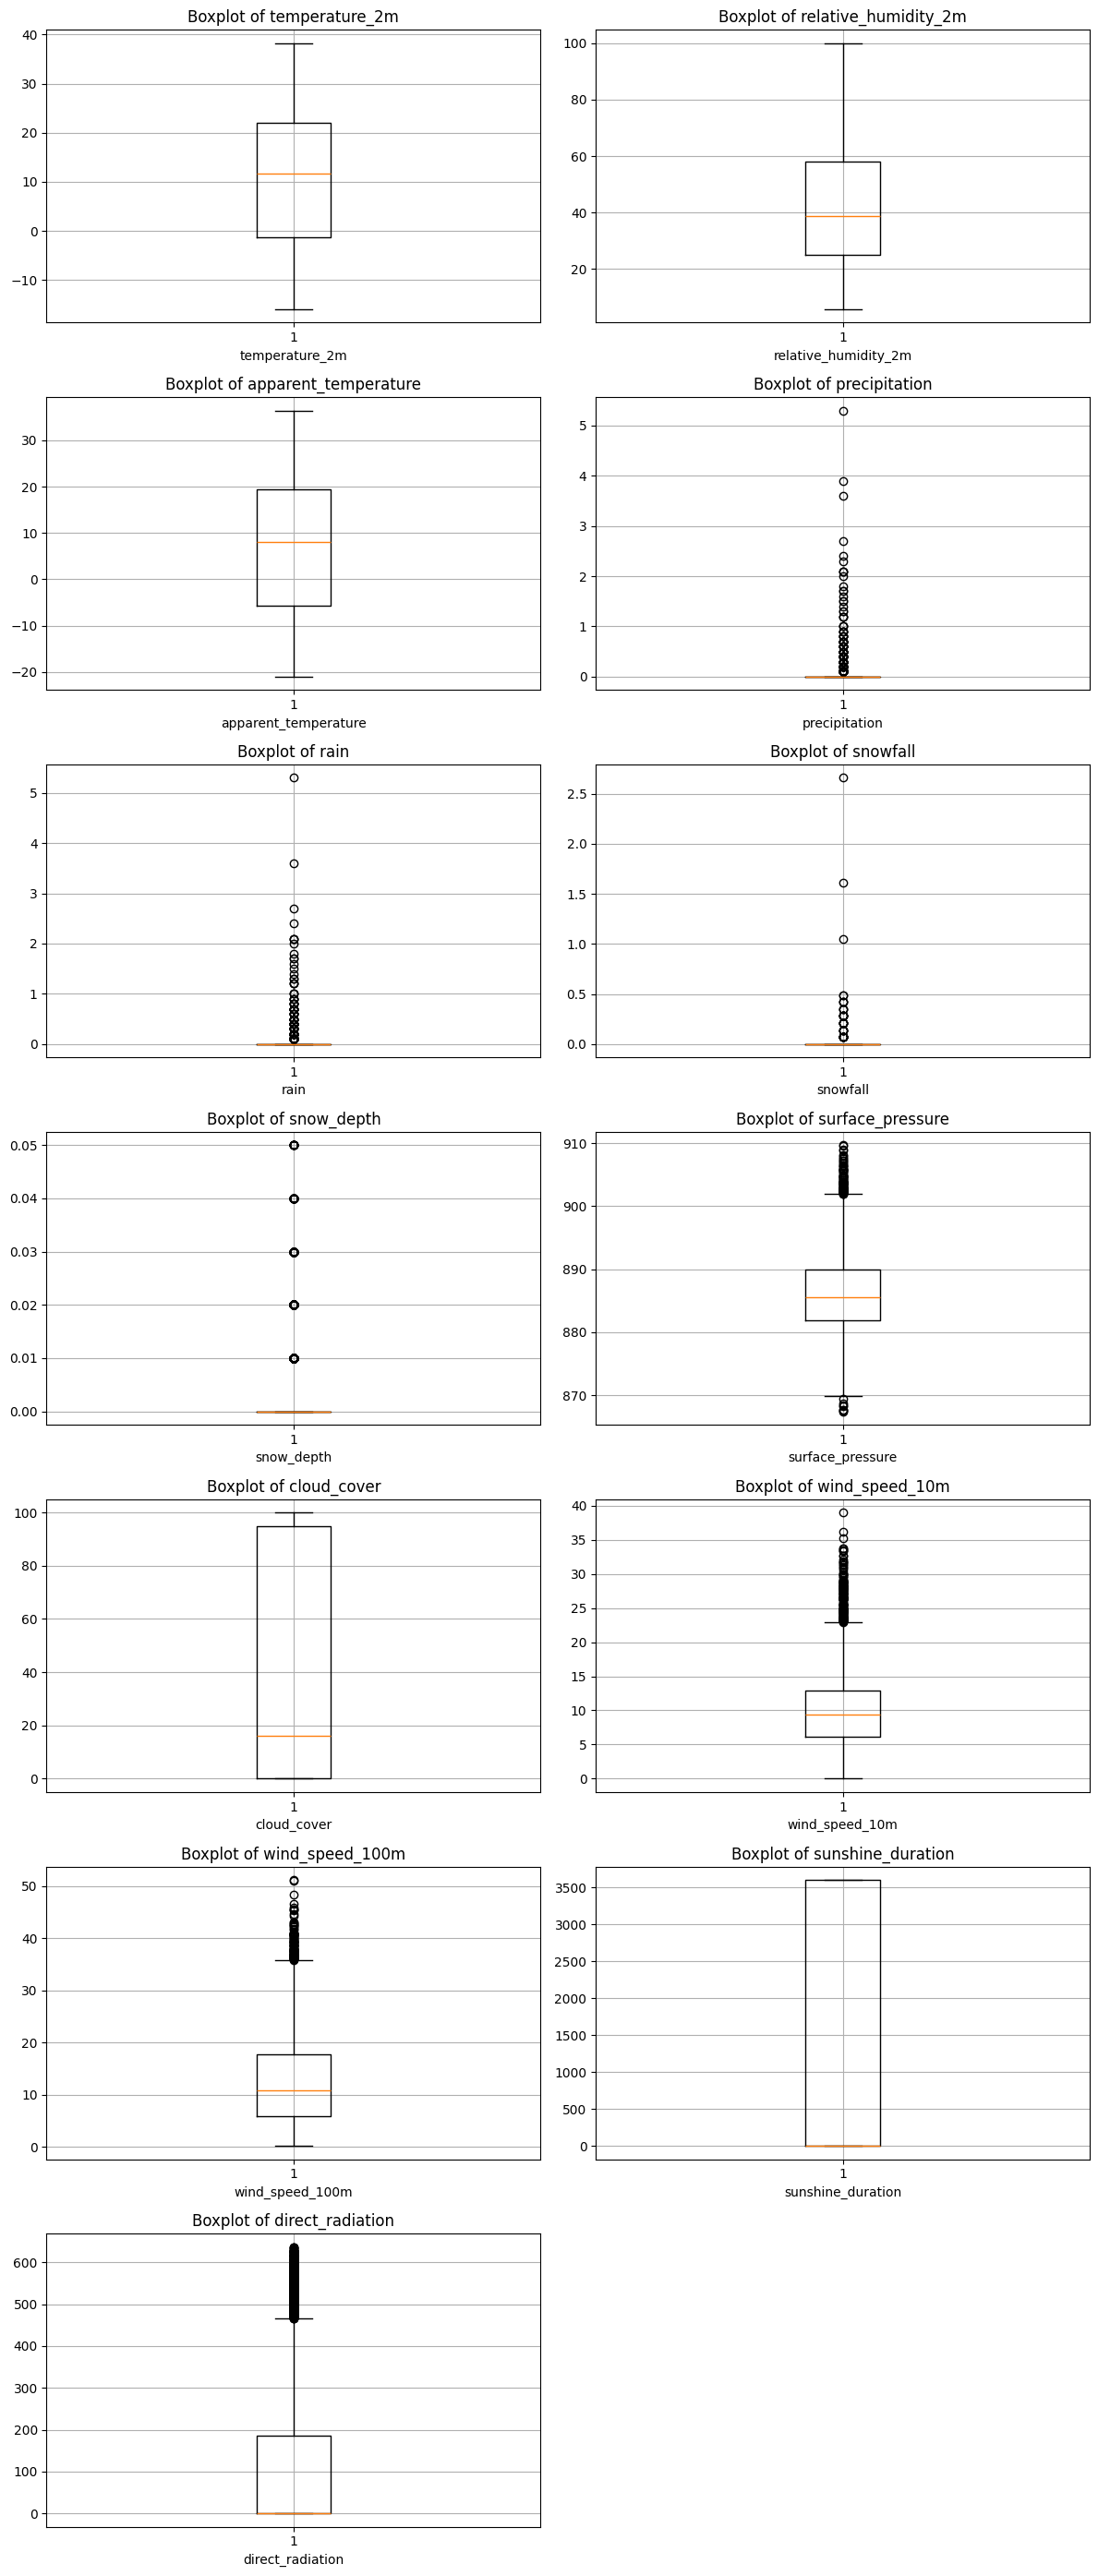

In [120]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Detection                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

numeric_columns = ["temperature_2m", "relative_humidity_2m", "apparent_temperature", "precipitation", "rain", "snowfall", "snow_depth",
                    "surface_pressure", "cloud_cover", "wind_speed_10m", "wind_speed_100m", "sunshine_duration", "direct_radiation"]

# 2 plots per row
rows = math.ceil(len(numeric_columns) / 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    data = pd.to_numeric(weather[col], errors='coerce').dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].grid(True)

# Remove any unused axes
for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [121]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Removal: Statistical Solution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zscore_threshold = 3
outlier_indices_per_column = {}
all_outlier_indices = set()
# remove outliers based on z-score
for col in numeric_columns:
    # Replace zeros with NaN and filter out non-positive values
    safe_col = weather[col].replace(0, np.nan)
    safe_col = safe_col[safe_col > 0]
    
    if safe_col.empty:
        continue
    
    # Log-transform and compute z-score
    log_transformed = np.log(safe_col)
    zscores = np.abs(zscore(log_transformed))
    zscore_series = pd.Series(zscores, index=log_transformed.index)

    # Find outliers
    outlier_indices = zscore_series[zscore_series > zscore_threshold].index
    outlier_indices_per_column[col] = list(outlier_indices)
    all_outlier_indices.update(outlier_indices)

    print(f"--> {len(outlier_indices)} outliers detected in '{col}'")

# Drop all outliers at once
total_rows = len(weather) # for dropped percentage of dataset
weather_outliers_removed = weather.drop(index=all_outlier_indices).reset_index(drop=True)

removed_rows = len(all_outlier_indices)
removed_percentage = round((removed_rows / total_rows) * 100, 2)

print(f"\nOutlier detection completed. Total rows removed: {len(all_outlier_indices)}, {removed_percentage}%")

--> 125 outliers detected in 'temperature_2m'
--> 23 outliers detected in 'relative_humidity_2m'
--> 121 outliers detected in 'apparent_temperature'
--> 1 outliers detected in 'precipitation'
--> 1 outliers detected in 'rain'
--> 1 outliers detected in 'snowfall'
--> 0 outliers detected in 'snow_depth'
--> 47 outliers detected in 'surface_pressure'
--> 0 outliers detected in 'cloud_cover'
--> 100 outliers detected in 'wind_speed_10m'
--> 60 outliers detected in 'wind_speed_100m'
--> 110 outliers detected in 'sunshine_duration'
--> 0 outliers detected in 'direct_radiation'

Outlier detection completed. Total rows removed: 567, 6.47%


In [122]:
# # # # # # # # # # # # # # # # # # # # # # # # #
#                                               #
# Merge trip and weather_outliers_removed data  #
#                                               #
# # # # # # # # # # # # # # # # # # # # # # # # # 

# check for duplicate timestamps and show them before removing
n_dupes = weather_outliers_removed["date"].duplicated().sum()
print(f"Duplicate weather_outliers_removed timestamps: {n_dupes}")
if n_dupes > 0:
    print(weather_outliers_removed[weather_outliers_removed["date"].duplicated(keep=False)].sort_values("date"))
    weather_outliers_removed = weather_outliers_removed.drop_duplicates(subset="date")

# create an hour-level key on the trip data
raw_data["trip_start_hour"] = raw_data["trip_start_timestamp"].dt.floor("h")

# merge on the hour key
df_merged_outliers_removed = raw_data.merge(weather_outliers_removed, left_on="trip_start_hour", right_on="date", how="left")
df_merged_outliers_removed = df_merged_outliers_removed.drop(columns=["date"])

assert len(df_merged_outliers_removed) == len(raw_data), "Row count changed after merge — unexpected duplicates remain!"
print(f"Merged shape: {df_merged_outliers_removed.shape}")
print(f"Weather NAs after merge: {df_merged_outliers_removed['temperature_2m'].isna().sum()}")
df_merged_outliers_removed.head()

Duplicate weather_outliers_removed timestamps: 0
Merged shape: (5637179, 48)
Weather NAs after merge: 347040


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,17031081000,17031081000,8.0,8.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,17031760900,17031062200,76.0,6.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,17031081000,17031071100,8.0,7.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,17031221300,17031071100,22.0,7.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,17031081000,17031031600,8.0,3.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0


In [123]:
df_merged_outliers_removed.isna().sum().to_frame(name="Null Count").assign(
    Null_Percent=lambda x: (x["Null Count"] / len(df_merged_outliers_removed) * 100).round(2)
)

,Null Count,Null_Percent
trip_id,0,0.00
taxi_id,0,0.00
trip_start_timestamp,0,0.00
trip_end_timestamp,0,0.00
trip_seconds,0,0.00
trip_miles,0,0.00
pickup_census_tract,0,0.00
dropoff_census_tract,0,0.00
pickup_community_area,0,0.00
dropoff_community_area,0,0.00


In [124]:
# # # # # # # # # # # # # # # #
#                             #
# Merge trip and weather data #
#                             #
# # # # # # # # # # # # # # # # 

# check for duplicate timestamps and show them before removing
n_dupes = weather["date"].duplicated().sum()
print(f"Duplicate weather timestamps: {n_dupes}")
if n_dupes > 0:
    print(weather[weather["date"].duplicated(keep=False)].sort_values("date"))
    weather = weather.drop_duplicates(subset="date")

# create an hour-level key on the trip data
raw_data["trip_start_hour"] = raw_data["trip_start_timestamp"].dt.floor("h")

# merge on the hour key
df_merged = raw_data.merge(weather, left_on="trip_start_hour", right_on="date", how="left")
df_merged = df_merged.drop(columns=["date"])

assert len(df_merged) == len(raw_data), "Row count changed after merge — unexpected duplicates remain!"
print(f"Merged shape: {df_merged.shape}")
print(f"Weather NAs after merge: {df_merged['temperature_2m'].isna().sum()}")
df_merged.head()

Duplicate weather timestamps: 1
      index                date  temperature_2m  relative_humidity_2m  \
7320  16110 2025-11-02 01:00:00             4.2             62.176895   
7321  16111 2025-11-02 01:00:00             4.0             62.128395   

      apparent_temperature  precipitation  rain  snowfall  snow_depth  \
7320              0.444203            0.0   0.0       0.0         0.0   
7321              0.165052            0.0   0.0       0.0         0.0   

      surface_pressure  cloud_cover  wind_speed_10m  wind_speed_100m  is_day  \
7320         887.82780          0.0        8.836514         4.889908     0.0   
7321         888.17206          0.0        9.199390         6.310277     0.0   

      sunshine_duration  direct_radiation  
7320                0.0               0.0  
7321                0.0               0.0  
Merged shape: (5637179, 48)
Weather NAs after merge: 0


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,17031081000,17031081000,8.0,8.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,17031760900,17031062200,76.0,6.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,17031081000,17031071100,8.0,7.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,17031221300,17031071100,22.0,7.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,17031081000,17031031600,8.0,3.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0


In [125]:
df_merged.isna().sum().to_frame(name="Null Count").assign(
    Null_Percent=lambda x: (x["Null Count"] / len(df_merged) * 100).round(2)
)

,Null Count,Null_Percent
trip_id,0,0.0
taxi_id,0,0.0
trip_start_timestamp,0,0.0
trip_end_timestamp,0,0.0
trip_seconds,0,0.0
trip_miles,0,0.0
pickup_census_tract,0,0.0
dropoff_census_tract,0,0.0
pickup_community_area,0,0.0
dropoff_community_area,0,0.0
